# Feature Engineering & Model Selection
# ensemble model

## The Titanic Disaster Survival Prediction Problem

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost scikit-optimize -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

# %matplotlib inline
# sns.set()

In [26]:
# Load the Titanic dataset

df_train = None
df_test = None

df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
#concatenating both train test set
survived_train = df_train['Survived']
data = pd.concat([df_train.drop('Survived', axis=1), df_test])

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 836 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  836 non-null    int64  
 1   Pclass       836 non-null    int64  
 2   Name         836 non-null    object 
 3   Sex          836 non-null    object 
 4   Age          664 non-null    float64
 5   SibSp        836 non-null    int64  
 6   Parch        836 non-null    int64  
 7   Ticket       836 non-null    object 
 8   Fare         834 non-null    float64
 9   Cabin        182 non-null    object 
 10  Embarked     836 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 78.4+ KB


In [29]:
# extracting 'Title' from Name column and plot distribution

data['Title'] = None
data['Title'] = data['Name'].apply(lambda x: re.search(r'\s(\w+)\.', x).group(1) if re.search(r'\s(\w+)\.', x) else None)


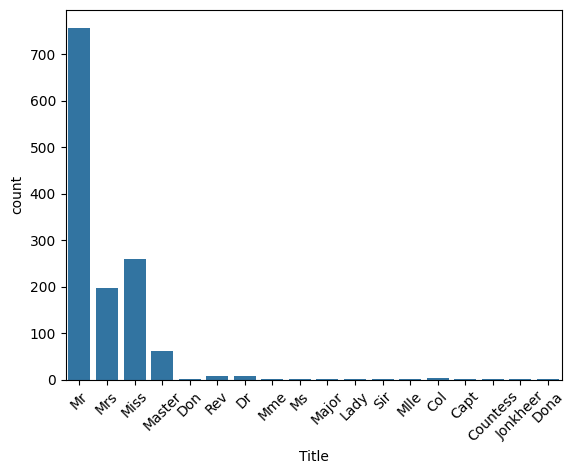

In [30]:
# Task: Plot the title count
sns.countplot(x='Title', data=data)
plt.xticks(rotation=45)
plt.show()

In [31]:
#normalizing similar titles and grouping rare cases

data['Title'].replace({'Mme':'Mrs', 'Ms': 'Miss', 'Mlle':'Miss'}, inplace=True)
special_titles = ['Don', 'Rev', 'Dr','Major','Lady','Sir','Col', 'Capt', 'Countess', 'Jonkheer', 'Dona']
data['Title'] = data['Title'].replace(special_titles, 'Special')


/tmp/ipykernel_1773/585422629.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Title'].replace({'Mme':'Mrs', 'Ms': 'Miss', 'Mlle':'Miss'}, inplace=True)


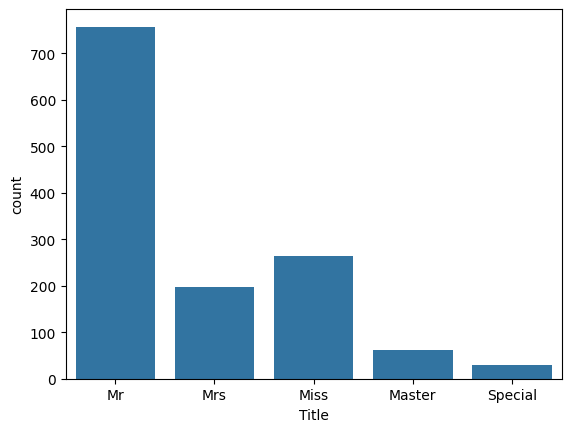

In [35]:
sns.countplot(x='Title', data=data)
plt.show()

In [36]:
# dropping irrelevant columns
data.drop(['Cabin', 'Name', 'PassengerId', 'Ticket'], axis=1, inplace=True)

In [37]:
#imputing missing values

data['Age'].fillna(data['Age'].median(), inplace=True)
data['Fare'].fillna(data['Fare'].median(), inplace=True)
data['Embarked'].fillna('S', inplace=True)

/tmp/ipykernel_1773/3340491684.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_1773/3340491684.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [38]:
# binning age and fare into categorical var

data['CatAge'] = None
data['CatFare'] = None

data['CatAge'] = pd.qcut(data['Age'], 4)
data['CatFare'] = pd.qcut(data['Fare'], 4)
data.drop(['Age', 'Fare'], axis=1, inplace=True)


In [39]:
# new col = Fam_Size and drop SibSp, Parch

data['Fam_Size'] = data['SibSp'] + data['Parch']
data.drop(['SibSp', 'Parch'], axis=1, inplace=True)


In [40]:
# avoid multicollinearity

data_dum = pd.get_dummies(data, drop_first=True)

In [41]:
data_dum.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Pclass                     1309 non-null   int64
 1   Fam_Size                   1309 non-null   int64
 2   Sex_male                   1309 non-null   bool 
 3   Embarked_Q                 1309 non-null   bool 
 4   Embarked_S                 1309 non-null   bool 
 5   Title_Miss                 1309 non-null   bool 
 6   Title_Mr                   1309 non-null   bool 
 7   Title_Mrs                  1309 non-null   bool 
 8   Title_Special              1309 non-null   bool 
 9   CatAge_(22.0, 28.0]        1309 non-null   bool 
 10  CatAge_(28.0, 35.0]        1309 non-null   bool 
 11  CatAge_(35.0, 80.0]        1309 non-null   bool 
 12  CatFare_(7.896, 14.454]    1309 non-null   bool 
 13  CatFare_(14.454, 31.275]   1309 non-null   bool 
 14  CatFare_(31.275, 512.329]  130

In [43]:
# train test split

data_train = data_dum.iloc[:891]
data_test = data_dum.iloc[891:]

X = data_train.values
test = data_test.values
y = survived_train.values

In [ ]:
#tuning decision tree

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
seed = 43
np.random.seed(seed)

param_dist = {'max_depth': np.arange(1, 10)}
clf = DecisionTreeClassifier(random_state=seed)
clf_cv = RandomizedSearchCV(clf, param_dist, n_iter=5, cv=5)
clf_cv.fit(X, y)

print("Tuned Decision Tree Parameters:", clf_cv.get_params())
print("Best CV score:", clf_cv.best_score_)


Tuned Decision Tree Parameters: {'cv': 5, 'error_score': nan, 'estimator__ccp_alpha': 0.0, 'estimator__class_weight': None, 'estimator__criterion': 'gini', 'estimator__max_depth': None, 'estimator__max_features': None, 'estimator__max_leaf_nodes': None, 'estimator__min_impurity_decrease': 0.0, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__min_weight_fraction_leaf': 0.0, 'estimator__monotonic_cst': None, 'estimator__random_state': 43, 'estimator__splitter': 'best', 'estimator': DecisionTreeClassifier(random_state=43), 'n_iter': 5, 'n_jobs': None, 'param_distributions': {'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9])}, 'pre_dispatch': '2*n_jobs', 'random_state': None, 'refit': True, 'return_train_score': False, 'scoring': None, 'verbose': 0}
Best CV score: 0.820387922917582


In [51]:
#tuning random forest
from sklearn.ensemble import RandomForestClassifier

rf_param_dist = {
    'max_depth': [None, 3, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'n_estimators': [50, 100, 200]
}
rf = RandomForestClassifier()
rf_cv = RandomizedSearchCV(rf, rf_param_dist, n_iter=5, cv=5)
rf_cv.fit(X, y)

print("Best RF Params:", rf_cv.best_params_)
print("Best CV Score:", rf_cv.best_score_)

Best RF Params: {'n_estimators': 50, 'max_features': 'sqrt', 'max_depth': 5}
Best CV Score: 0.8226476680685455


In [54]:
# tuning xgboost with bayesian optimization

from skopt import BayesSearchCV
from xgboost import XGBClassifier

param_space = {
  'max_depth': (3, 8),
  'n_estimators': (50, 100),
  'learning_rate': (0.01, 0.2, 'log-uniform')
}
xgb = XGBClassifier(random_state=seed, use_label_encoder=False, eval_metric='logloss')
xgb_cv = BayesSearchCV(xgb, param_space, n_iter=5, cv=5)
xgb_cv.fit(X, y)

print("Best XGBoost Params:", xgb_cv.best_params_)
print("Best CV Score:", xgb_cv.best_score_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:01:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:01:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:01:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:01:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best XGBoost Params: OrderedDict({'learning_rate': 0.01287801839673963, 'max_depth': 4, 'n_estimators': 64})
Best CV Score: 0.8147950536689473


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:01:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [56]:
print("OVerall result::")

print(f"Decision Tree: {clf_cv.best_score_}\nRandom Forest: {rf_cv.best_score_}\nXGBoost:{xgb_cv.best_score_}")

OVerall result::
Decision Tree: 0.820387922917582
Random Forest: 0.8226476680685455
XGBoost:0.8147950536689473
